In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy.linalg as linalg

In [13]:
np.set_printoptions(precision = 1)

Initial diagonal matrix D:
 [[1 0 0 0 0]
 [0 2 0 0 0]
 [0 0 2 0 0]
 [0 0 0 2 0]
 [0 0 0 0 2]]

Constructed Matrix A:
 [[ 1.0393 -0.0979 -0.0974 -0.0969 -0.0964]
 [-0.0979  1.99   -0.0099 -0.0099 -0.0098]
 [-0.0974 -0.0099  1.9901 -0.0098 -0.0098]
 [-0.0969 -0.0099 -0.0098  1.9902 -0.0097]
 [-0.0964 -0.0098 -0.0098 -0.0097  1.9903]]

Eigenvalues:
 [1. 2. 2. 2. 2.]

Off-diagonal entries:
A[0,1] = -0.0979
A[0,2] = -0.0974
A[0,3] = -0.0969
A[0,4] = -0.0964
A[1,0] = -0.0979
A[1,2] = -0.0099
A[1,3] = -0.0099
A[1,4] = -0.0098
A[2,0] = -0.0974
A[2,1] = -0.0099
A[2,3] = -0.0098
A[2,4] = -0.0098
A[3,0] = -0.0969
A[3,1] = -0.0099
A[3,2] = -0.0098
A[3,4] = -0.0097
A[4,0] = -0.0964
A[4,1] = -0.0098
A[4,2] = -0.0098
A[4,3] = -0.0097


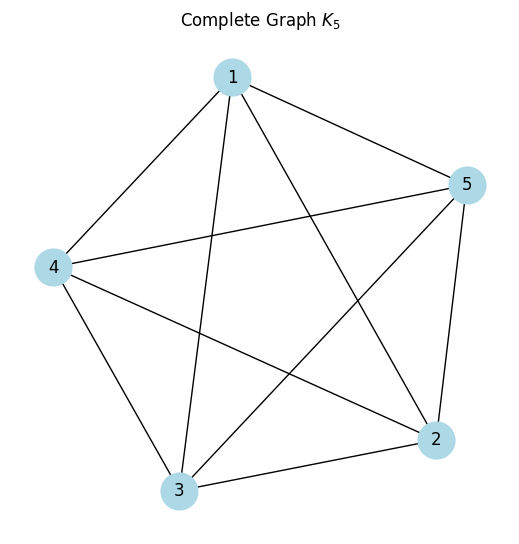

In [23]:
# --------- GIVENS ROTATION ---------
def givens_rotation(theta, n, i, j):
    R = np.eye(n)
    R[i, i] = np.cos(theta)
    R[j, j] = np.cos(theta)
    R[i, j] = -np.sin(theta)
    R[j, i] = np.sin(theta)
    return R

# --------- PARAMETERS ---------
n = 5

# Spectrum (λ1 < λ2 condition satisfied)
eigenvalues = [1, 2, 2, 2, 2]
D = np.diag(eigenvalues)

print("Initial diagonal matrix D:\n", D)

# --------- APPLY GIVENS ROTATIONS ---------
A = D.copy()
angles = [0.1, 0.1, 0.1, 0.1]

for k in range(1, n):
    R = givens_rotation(angles[k-1], n, 0, k)
    A = R @ A @ R.T

print("\nConstructed Matrix A:\n", np.round(A, 4))

# --------- EIGENVALUES ---------
eigvals = np.linalg.eigvalsh(A)
print("\nEigenvalues:\n", np.round(eigvals, 4))

# --------- CHECK OFF-DIAGONAL ---------
print("\nOff-diagonal entries:")
for i in range(n):
    for j in range(n):
        if i != j:
            print(f"A[{i},{j}] = {A[i,j]:.4f}")

# --------- GRAPH CONSTRUCTION ---------
G = nx.Graph()
G.add_nodes_from(range(1, n+1))

# Add edges (complete graph, ignore weights)
for i in range(n):
    for j in range(i+1, n):
        G.add_edge(i+1, j+1)

# --------- PLOT GRAPH (NO WEIGHTS) ---------
plt.figure(figsize=(5,5))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    edge_color='black',
    node_size=700,
    font_size=12
)

plt.title("Complete Graph $K_5$")
plt.show()

Initial diagonal matrix D:
 [[1 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 2 0 0 0]
 [0 0 0 2 0 0]
 [0 0 0 0 2 0]
 [0 0 0 0 0 5]]

Constructed Matrix A:
 [[ 1.0788 -0.0974 -0.0969 -0.0964 -0.0959 -0.3934]
 [-0.0974  1.99   -0.0099 -0.0099 -0.0098 -0.0098]
 [-0.0969 -0.0099  1.9901 -0.0098 -0.0098 -0.0097]
 [-0.0964 -0.0099 -0.0098  1.9902 -0.0097 -0.0097]
 [-0.0959 -0.0098 -0.0098 -0.0097  1.9903 -0.0096]
 [-0.3934 -0.0098 -0.0097 -0.0097 -0.0096  4.9605]]

Eigenvalues:
 [1. 2. 2. 2. 2. 5.]

Off-diagonal entries:
A[0,1] = -0.0974
A[0,2] = -0.0969
A[0,3] = -0.0964
A[0,4] = -0.0959
A[0,5] = -0.3934
A[1,0] = -0.0974
A[1,2] = -0.0099
A[1,3] = -0.0099
A[1,4] = -0.0098
A[1,5] = -0.0098
A[2,0] = -0.0969
A[2,1] = -0.0099
A[2,3] = -0.0098
A[2,4] = -0.0098
A[2,5] = -0.0097
A[3,0] = -0.0964
A[3,1] = -0.0099
A[3,2] = -0.0098
A[3,4] = -0.0097
A[3,5] = -0.0097
A[4,0] = -0.0959
A[4,1] = -0.0098
A[4,2] = -0.0098
A[4,3] = -0.0097
A[4,5] = -0.0096
A[5,0] = -0.3934
A[5,1] = -0.0098
A[5,2] = -0.0097
A[5,3] = -0.0097

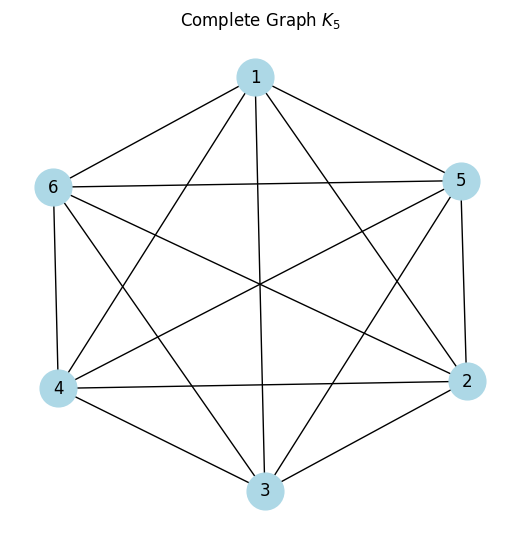

In [25]:
# --------- PARAMETERS ---------
n = 6

# Spectrum (λ1 < λ2 condition satisfied)
eigenvalues = [1, 2, 2, 2, 2, 5]
D = np.diag(eigenvalues)

print("Initial diagonal matrix D:\n", D)

# --------- APPLY GIVENS ROTATIONS ---------
A = D.copy()
angles = [0.1, 0.1, 0.1, 0.1, 0.1]

for k in range(1, n):
    R = givens_rotation(angles[k-1], n, 0, k)
    A = R @ A @ R.T

print("\nConstructed Matrix A:\n", np.round(A, 4))

# --------- EIGENVALUES ---------
eigvals = np.linalg.eigvalsh(A)
print("\nEigenvalues:\n", np.round(eigvals, 4))

# --------- CHECK OFF-DIAGONAL ---------
print("\nOff-diagonal entries:")
for i in range(n):
    for j in range(n):
        if i != j:
            print(f"A[{i},{j}] = {A[i,j]:.4f}")

# --------- GRAPH CONSTRUCTION ---------
G = nx.Graph()
G.add_nodes_from(range(1, n+1))

# Add edges (complete graph, ignore weights)
for i in range(n):
    for j in range(i+1, n):
        G.add_edge(i+1, j+1)

# --------- PLOT GRAPH (NO WEIGHTS) ---------
plt.figure(figsize=(5,5))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    edge_color='black',
    node_size=700,
    font_size=12
)

plt.title("Complete Graph $K_6$")
plt.show()